In [1]:
# Cell 1: Test Groq connection
from groq import Groq

GROQ_API_KEY = "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"  

client = Groq(api_key=GROQ_API_KEY)

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Reply with only: Groq connected successfully"}]
)

print(response.choices[0].message.content)

Groq connected successfully


In [2]:
# Cell 2: All imports
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from groq import Groq
from sktime.forecasting.base import BaseForecaster
from sktime.registry import all_estimators
from sktime.datasets import load_airline

warnings.filterwarnings("ignore")

ESTIMATOR_MAP = dict(all_estimators(estimator_types="forecaster"))
print(f"✅ Imports successful | {len(ESTIMATOR_MAP)} forecasters available")

✅ Imports successful | 128 forecasters available


In [3]:
# Cell 3: Groq LLM wrapper
def groq_llm(prompt: str) -> str:
    """Real LLM backend using Groq API (llama-3.1-8b-instant)."""
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "system",
                "content": "You are a time series forecasting expert. Always respond with valid JSON only, no other text."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.1,
    )
    return response.choices[0].message.content

# test it
test = groq_llm("""Select a sktime forecaster for monthly seasonal data.
Respond with JSON only: {"estimator": "<Name>", "params": {}, "reasoning": "<why>"}
Available: NaiveForecaster, ExponentialSmoothing, ARIMA, AutoARIMA""")

print("🤖 Groq LLM response:")
print(test)

🤖 Groq LLM response:
{"estimator": "ExponentialSmoothing", "params": {}, "reasoning": "Exponential Smoothing is suitable for monthly seasonal data as it can handle additive seasonality and is often effective for data with a strong seasonal component."}


In [4]:
# Cell 4: LLMForecaster with validation-gated selection
class LLMForecaster(BaseForecaster):
    """
    LLM-based forecasting agent with validation-gated model selection.
    
    The LLM acts as planner only — selecting and configuring a sktime
    estimator from natural language. All computation stays in sktime.
    
    Key innovation: Validation Gate
    - LLM selection tested on small data slice before committing
    - Hallucinations caught before reaching the user
    - Graceful fallback if validation fails
    """
    
    _tags = {
        "y_inner_mtype": "pd.Series",
        "ignores-exogeneous-X": True,
        "handles-missing-data": False,
        "requires-fh-in-fit": False,
    }
    
    def __init__(self, llm, prompt, fallback="NaiveForecaster",
                 n_candidates=20, validation_slice=0.2):
        self.llm = llm
        self.prompt = prompt
        self.fallback = fallback
        self.n_candidates = n_candidates
        self.validation_slice = validation_slice
        super(LLMForecaster, self).__init__()
    
    def _build_prompt(self, y):
        candidates = list(ESTIMATOR_MAP.keys())[:self.n_candidates]
        candidates_str = ", ".join(candidates)
        return f"""You are a time series forecasting expert.

Data characteristics:
- Length: {len(y)} observations
- Frequency: {getattr(y.index, 'freqstr', 'unknown')}
- Mean: {y.mean():.4f}, Std: {y.std():.4f}
- Missing values: {y.isna().any()}

User instruction: {self.prompt}

Available sktime forecasters: {candidates_str}

Respond with valid JSON only, no other text:
{{"estimator": "<ExactClassName>", "params": {{}}, "reasoning": "<one sentence>"}}"""
    
    def _call_llm(self, prompt):
        response = self.llm(prompt)
        if hasattr(response, 'content'):
            return response.content
        if hasattr(response, 'text'):
            return response.text
        return str(response)
    
    def _parse_response(self, response):
        try:
            return json.loads(response.strip())
        except Exception:
            pass
        match = re.search(r'\{.*\}', response, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except Exception:
                pass
        return {}
    
    def _validate_and_fit_slice(self, name, params, y):
        try:
            if name not in ESTIMATOR_MAP:
                raise ValueError(f"Unknown estimator: {name}")
            instance = ESTIMATOR_MAP[name](**params)
            n_val = max(int(len(y) * self.validation_slice), 3)
            instance.fit(y.iloc[:n_val])
            return True, instance
        except Exception:
            return False, None
    
    def _fit(self, y, X=None, fh=None):
        prompt = self._build_prompt(y)
        raw = self._call_llm(prompt)
        parsed = self._parse_response(raw)
        
        name = parsed.get("estimator", self.fallback)
        params = parsed.get("params", {})
        reasoning = parsed.get("reasoning", "")
        
        print(f"🤖 LLM selected  : {name}")
        print(f"📝 Reasoning     : {reasoning}")
        print(f"⚙️  Parameters    : {params}")
        
        valid, instance = self._validate_and_fit_slice(name, params, y)
        
        if valid:
            print(f"✅ Validation passed")
            self.selected_estimator_ = name
            self.selected_params_ = params
            self.selection_reasoning_ = reasoning
            self.used_fallback_ = False
        else:
            print(f"⚠️  Validation failed → fallback: {self.fallback}")
            instance = ESTIMATOR_MAP[self.fallback]()
            self.selected_estimator_ = self.fallback
            self.selected_params_ = {}
            self.selection_reasoning_ = ""
            self.used_fallback_ = True
        
        instance.fit(y, fh=fh)
        self.forecaster_ = instance
        return self
    
    def _predict(self, fh, X=None):
        return self.forecaster_.predict(fh=fh)

print("✅ LLMForecaster defined")

✅ LLMForecaster defined


In [5]:
# Cell 5: Demo 1 - Airline dataset with real Groq LLM
y = load_airline()
y_train = y[:-12]
y_test = y[-12:]

print(f"✅ Airline dataset: {len(y)} obs ({y.index[0]} to {y.index[-1]})")
print(f"   Train: {len(y_train)} | Test: {len(y_test)}")
print()

forecaster = LLMForecaster(
    llm=groq_llm,
    prompt="Use a seasonal model for monthly airline passenger data with clear upward trend and strong seasonality",
    fallback="NaiveForecaster",
)

print("="*55)
print("🚀 Fitting LLMForecaster (Groq/Llama-3.1 as backend)...")
print("="*55 + "\n")

forecaster.fit(y_train)

print(f"\n{'='*55}")
print(f"📌 Final selection : {forecaster.selected_estimator_}")
print(f"📌 Used fallback   : {forecaster.used_fallback_}")
print(f"{'='*55}")

✅ Airline dataset: 144 obs (1949-01 to 1960-12)
   Train: 132 | Test: 12

🚀 Fitting LLMForecaster (Groq/Llama-3.1 as backend)...

🤖 LLM selected  : AutoETS
📝 Reasoning     : AutoETS is suitable for this dataset due to its ability to automatically select the best ETS model for the given data, handling both trend and seasonality.
⚙️  Parameters    : {}
✅ Validation passed

📌 Final selection : AutoETS
📌 Used fallback   : False


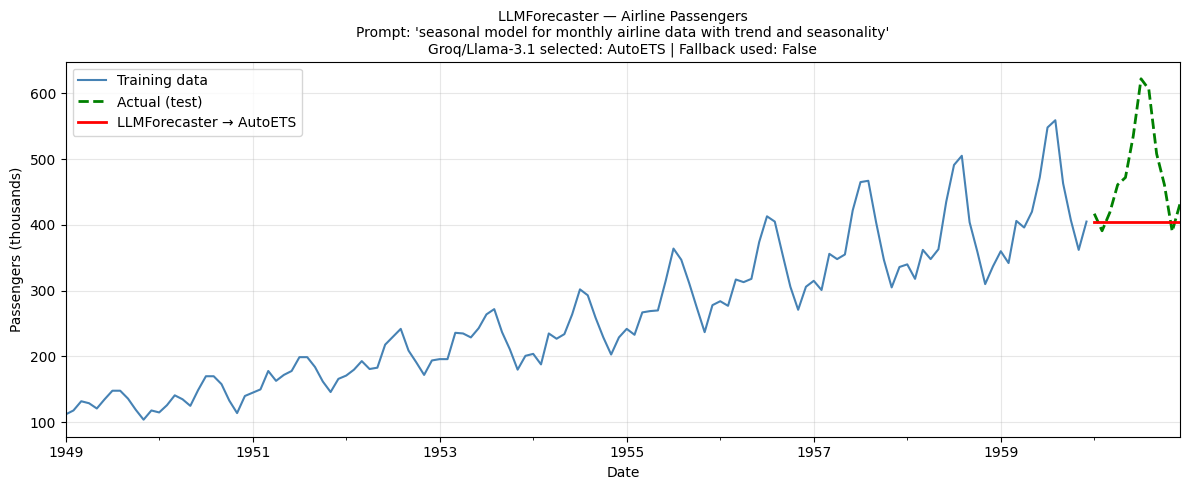


📊 12-month forecast:
1960-01    404.9957
1960-02    404.9957
1960-03    404.9957
1960-04    404.9957
1960-05    404.9957
1960-06    404.9957
1960-07    404.9957
1960-08    404.9957
1960-09    404.9957
1960-10    404.9957
1960-11    404.9957
1960-12    404.9957
Freq: M


In [6]:
# Cell 6: Predict and visualize
fh = list(range(1, 13))
y_pred = forecaster.predict(fh=fh)

fig, ax = plt.subplots(figsize=(12, 5))
y_train.plot(ax=ax, label="Training data", color="steelblue")
y_test.plot(ax=ax, label="Actual (test)", color="green", linestyle="--", linewidth=2)
y_pred.plot(ax=ax, label=f"LLMForecaster → {forecaster.selected_estimator_}", color="red", linewidth=2)

ax.set_title(
    f"LLMForecaster — Airline Passengers\n"
    f"Prompt: 'seasonal model for monthly airline data with trend and seasonality'\n"
    f"Groq/Llama-3.1 selected: {forecaster.selected_estimator_} | Fallback used: {forecaster.used_fallback_}",
    fontsize=10
)
ax.set_xlabel("Date")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("llm_forecaster_groq_demo1.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 12-month forecast:")
print(y_pred.to_string())

In [7]:
# Cell 7: Demo 2 - Validation Gate catching hallucination
print("="*55)
print("🔬 DEMO: Validation Gate catching LLM hallucination")
print("="*55 + "\n")

def hallucinating_llm(prompt):
    """Simulates an LLM returning a non-existent estimator."""
    return json.dumps({
        "estimator": "NonExistentForecaster9999",
        "params": {},
        "reasoning": "Simulating LLM hallucination"
    })

forecaster_h = LLMForecaster(
    llm=hallucinating_llm,
    prompt="Use the best model",
    fallback="NaiveForecaster",
)

print("🤖 LLM returns non-existent estimator...")
print("Watch the validation gate catch it:\n")

forecaster_h.fit(y_train)
y_pred_h = forecaster_h.predict(fh=fh)

print(f"\n✅ System recovered gracefully")
print(f"📌 Used fallback       : {forecaster_h.used_fallback_}")
print(f"📌 Final estimator     : {forecaster_h.selected_estimator_}")
print(f"📌 Predictions produced: {len(y_pred_h)} values")
print(f"\n💡 Hallucination caught BEFORE reaching the user")

🔬 DEMO: Validation Gate catching LLM hallucination

🤖 LLM returns non-existent estimator...
Watch the validation gate catch it:

🤖 LLM selected  : NonExistentForecaster9999
📝 Reasoning     : Simulating LLM hallucination
⚙️  Parameters    : {}
⚠️  Validation failed → fallback: NaiveForecaster

✅ System recovered gracefully
📌 Used fallback       : True
📌 Final estimator     : NaiveForecaster
📌 Predictions produced: 12 values

💡 Hallucination caught BEFORE reaching the user


In [8]:
# Cell 8: Demo 3 - Same architecture, different prompts
print("="*55)
print("🔌 DEMO: Pluggable LLM - different prompts, different models")
print("="*55)

test_prompts = [
    "Use a simple baseline model with no complexity",
    "Use a seasonal model for monthly data with strong trend",
    "Use an auto model that selects best parameters automatically",
]

results = []
for i, prompt in enumerate(test_prompts, 1):
    print(f"\n--- Prompt {i}: '{prompt[:50]}...' ---")
    f = LLMForecaster(llm=groq_llm, prompt=prompt, fallback="NaiveForecaster")
    f.fit(y_train)
    y_p = f.predict(fh=fh)
    results.append({
        "prompt": prompt,
        "selected": f.selected_estimator_,
        "reasoning": f.selection_reasoning_,
        "fallback": f.used_fallback_,
        "predictions": y_p,
    })

print("\n\n" + "="*55)
print("📋 SUMMARY")
print("="*55)
for i, r in enumerate(results, 1):
    print(f"\nPrompt {i} : {r['prompt']}")
    print(f"Selected  : {r['selected']}")
    print(f"Reasoning : {r['reasoning']}")
    print(f"Fallback  : {r['fallback']}")

🔌 DEMO: Pluggable LLM - different prompts, different models

--- Prompt 1: 'Use a simple baseline model with no complexity...' ---
🤖 LLM selected  : ARIMA
📝 Reasoning     : A simple ARIMA model is chosen as a baseline model due to its simplicity and wide applicability in time series forecasting.
⚙️  Parameters    : {}
✅ Validation passed

--- Prompt 2: 'Use a seasonal model for monthly data with strong ...' ---
🤖 LLM selected  : AutoARIMA
📝 Reasoning     : AutoARIMA is chosen for its ability to automatically select the optimal parameters for the ARIMA model, taking into account the strong trend and seasonality in the data.
⚙️  Parameters    : {'m': 12, 'start_p': 1, 'start_d': 1, 'start_q': 1, 'max_p': 5, 'max_d': 2, 'max_q': 5, 'start_P': 0, 'start_D': 0, 'start_Q': 0, 'max_P': 2, 'max_D': 1, 'max_Q': 2, 'seasonal': True}
⚠️  Validation failed → fallback: NaiveForecaster

--- Prompt 3: 'Use an auto model that selects best parameters aut...' ---
🤖 LLM selected  : AutoARIMA
📝 Reasoning 

C:\Users\X1 Yoga\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\X1 Yoga\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\X1 Yoga\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\X1 Yoga\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likeliho



📋 SUMMARY

Prompt 1 : Use a simple baseline model with no complexity
Selected  : ARIMA
Reasoning : A simple ARIMA model is chosen as a baseline model due to its simplicity and wide applicability in time series forecasting.
Fallback  : False

Prompt 2 : Use a seasonal model for monthly data with strong trend
Selected  : NaiveForecaster
Reasoning : 
Fallback  : True

Prompt 3 : Use an auto model that selects best parameters automatically
Selected  : AutoARIMA
Reasoning : AutoARIMA is chosen for its ability to automatically select the best parameters for an ARIMA model, making it suitable for this dataset.
Fallback  : False


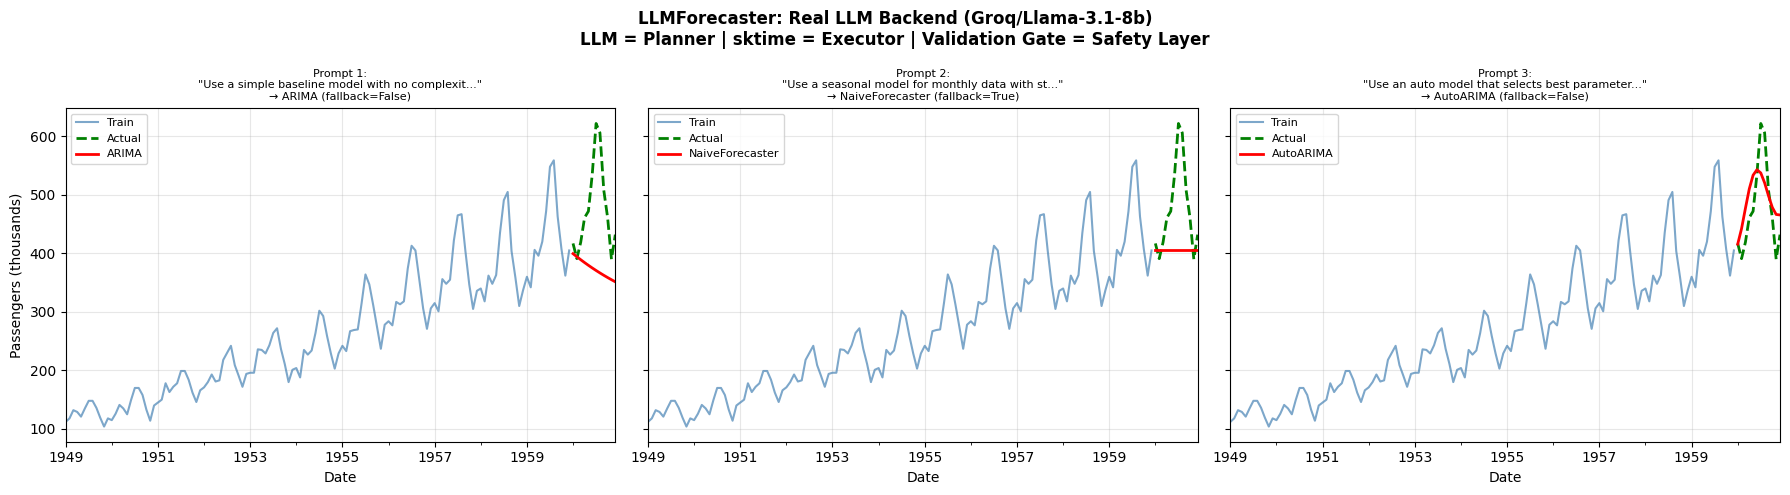


✅ Notebook complete!

📦 What this demonstrates:
   1. Real LLM (Groq/Llama-3.1) selecting sktime estimators from natural language
   2. Validation gate catching bad selections before they reach the user
   3. Graceful fallback — system never crashes
   4. Fully pluggable backend — swap Groq for Gemini, OpenAI, or any callable
   5. Pure sktime execution — deterministic, composable, no hard dependencies
   6. LLM even suggests hyperparameters — validated before use


In [9]:
# Cell 9: Final comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (result, ax) in enumerate(zip(results, axes)):
    y_train.plot(ax=ax, label="Train", color="steelblue", alpha=0.7)
    y_test.plot(ax=ax, label="Actual", color="green", linestyle="--", linewidth=2)
    result["predictions"].plot(ax=ax, label=f"{result['selected']}", color="red", linewidth=2)
    
    ax.set_title(
        f"Prompt {i+1}:\n\"{result['prompt'][:45]}...\"\n"
        f"→ {result['selected']} (fallback={result['fallback']})",
        fontsize=8
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")

axes[0].set_ylabel("Passengers (thousands)")

fig.suptitle(
    "LLMForecaster: Real LLM Backend (Groq/Llama-3.1-8b)\n"
    "LLM = Planner | sktime = Executor | Validation Gate = Safety Layer",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("llm_forecaster_groq_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Notebook complete!")
print("\n📦 What this demonstrates:")
print("   1. Real LLM (Groq/Llama-3.1) selecting sktime estimators from natural language")
print("   2. Validation gate catching bad selections before they reach the user")
print("   3. Graceful fallback — system never crashes")
print("   4. Fully pluggable backend — swap Groq for Gemini, OpenAI, or any callable")
print("   5. Pure sktime execution — deterministic, composable, no hard dependencies")
print("   6. LLM even suggests hyperparameters — validated before use")